## Data Cleaning and Preprocessing
The data used is a food delivery orders dataset. Issues in the dataset include inconsistent data types, missing values, irregular categorical entries, textual noise, duplications, and potential outliers. The objective here is to impose structure, correctness, and analytical readiness on the raw data so that it may be reliably used for subsequent tasks.

### Preliminary Examination of the Data
A thorough initial exploration is essential for understanding the structure and condition of the dataset before applying cleaning operations.
This stage seeks to identify data quality issues early and develop an informed strategy for resolving them.

#### Importing Libraries and Loading the Data
Essential Python libraries for data manipulation, statistical summarisation, and visual inspection include libraries such as Pandas, NumPy, Matplotlib, and Seaborn. These libraries form the foundational tools needed to conduct a methodical and reproducible cleaning workflow.

In [1]:
import pandas as pd  # Core library for data manipulation and preprocessing
import numpy as np  # Numerical computing library used for arrays and mathematical operations
import matplotlib.pyplot as plt  # Plotting library for generating static visualisations
import seaborn as sns  # Statistical visualisation library built on top of matplotlib

In [2]:
df = pd.read_csv('food_delivery_dataset.csv')  # Load the raw food delivery dataset into a pandas DataFrame

In [3]:
df.head()  # Top few rows of the data frame

,order_id,customer_name,customer_age,customer_city,order_date,delivery_timestamp,restaurant_name,food_item,quantity,price,discount,payment_method,delivery_rating,special_instructions,order_status,delivery_time_minutes
0,11484,sara khan,twenty,Bangalore,09-11-2025,NaN,Biryani House,Pizza,three,200.00,5,Card,5.0,Less sugar,cancelled,-5.0
1,19268,alexa,twenty,Hyderabad,15-10-2025,NaN,Foodie Corner,Pasta,2,NaN,10,Cash,1.0,No onions,cancelled,NaN
2,16396,Sohan Kumar,56,Mumbai,2025-10-05 06:15:29.465901,2025-11-28 12:15:29.465918,pizza hub,Pasta,2,200.00,15,wallet,6.0,No onions,cancelled,-5.0
3,13943,PRIYA SINGH,32,delhi,2025-11-28 06:15:29.465935,2025-11-27 10:15:29.465955,Pizza Hub,Pizza,1,200.00,5%,CASH,2.0,,cancelled,NaN
4,18004,sara khan,twenty,Bangalore,10/22/2025,2025-11-28 15:15:29.465989,Pizza Hub,Pizza,2,161.33,NaN,wallet,NaN,NaN,cancelled,37.0


In [4]:
# Subset of features used
features = ['order_id', 'price', 'delivery_rating', 'delivery_time_minutes',
            'customer_city', 'order_date', 'restaurant_name', 'food_item', 'quantity',
            'discount', 'order_status', 'payment_method']

df = df[features]

In [5]:
df.head()  # Top few rows of the data frame

,order_id,price,delivery_rating,delivery_time_minutes,customer_city,order_date,restaurant_name,food_item,quantity,discount,order_status,payment_method
0,11484,200.00,5.0,-5.0,Bangalore,09-11-2025,Biryani House,Pizza,three,5,cancelled,Card
1,19268,NaN,1.0,NaN,Hyderabad,15-10-2025,Foodie Corner,Pasta,2,10,cancelled,Cash
2,16396,200.00,6.0,-5.0,Mumbai,2025-10-05 06:15:29.465901,pizza hub,Pasta,2,15,cancelled,wallet
3,13943,200.00,2.0,NaN,delhi,2025-11-28 06:15:29.465935,Pizza Hub,Pizza,1,5%,cancelled,CASH
4,18004,161.33,NaN,37.0,Bangalore,10/22/2025,Pizza Hub,Pizza,2,NaN,cancelled,wallet


#### Inspecting Data Types and Structural Properties
A concise summary of feature data types, extent of missing values, memory usage, and structural metadata helps in better understanding the data. This inspection helps identify variables stored in inappropriate formats and highlights fields that require type correction or imputation.

In [6]:
df.info()  # View data types and summary of null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               350 non-null    int64  
 1   price                  170 non-null    float64
 2   delivery_rating        296 non-null    float64
 3   delivery_time_minutes  209 non-null    float64
 4   customer_city          318 non-null    object 
 5   order_date             350 non-null    object 
 6   restaurant_name        350 non-null    object 
 7   food_item              350 non-null    object 
 8   quantity               302 non-null    object 
 9   discount               247 non-null    object 
 10  order_status           350 non-null    object 
 11  payment_method         350 non-null    object 
dtypes: float64(3), int64(1), object(8)
memory usage: 32.9+ KB


In [7]:
df.shape  # Examining the shape and size of the data

(350, 12)

#### Examining Summary Statistics
A descriptive statistical overview of both numerical and categorical variables helps in further understanding the data. This step provides insight into the distribution of numerical features, central tendencies and dispersion, frequency patterns within categorical fields, and potential anomalies, outliers, or irregularities. Such summaries allow us to assess the dataset’s internal consistency and detect values that warrant deeper investigation.

In [8]:
df.describe(include = 'all')  # View descriptive statistics for all columns

,order_id,price,delivery_rating,delivery_time_minutes,customer_city,order_date,restaurant_name,food_item,quantity,discount,order_status,payment_method
count,350.000000,170.000000,296.000000,209.000000,318,350,350,350,302,247,350,350
unique,NaN,NaN,NaN,NaN,8,269,7,8,4,4,5,6
top,NaN,NaN,NaN,NaN,Pune,11/07/2025,The Spice Route,momos,2,10,Cancelled,Card
freq,NaN,NaN,NaN,NaN,48,6,67,57,130,70,80,72
mean,14958.694286,250.734235,3.094595,25.023923,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,2850.104549,93.478849,1.989252,32.526386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,10064.000000,105.950000,0.000000,-5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,12695.000000,200.000000,1.000000,-5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,14736.500000,200.000000,3.000000,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,17400.000000,265.797500,5.000000,53.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Quantifying Missing Values
A detailed breakdown of missingness should be computed. This enables us to determine the variables most affected by missing data, patterns of missingness across the dataset, and potential implications for downstream analyses. Understanding the nature and extent of missing data is crucial for choosing suitable imputation or removal strategies.

In [9]:
df.isnull().sum()  # Count missing values in each column

order_id                   0
price                    180
delivery_rating           54
delivery_time_minutes    141
customer_city             32
order_date                 0
restaurant_name            0
food_item                  0
quantity                  48
discount                 103
order_status               0
payment_method             0
dtype: int64

#### Viewing Representative Samples of the Data
Inspecting random subsets of observations is also a good way to get a sense of the data. This provides a more holistic preliminary understanding of the data.

In [10]:
df.sample(10)  # Display a random sample of rows

,order_id,price,delivery_rating,delivery_time_minutes,customer_city,order_date,restaurant_name,food_item,quantity,discount,order_status,payment_method
154,18096,434.70,2.0,NaN,Hyderabad,2025-11-06 06:15:29.471008,Biryani House,momos,NaN,5%,Cancelled,CASH
39,14737,NaN,6.0,NaN,Mumbai,2025-11-22 06:15:29.467285,Foodie Corner,Coke,1,10,Cancelled,CASH
304,11895,NaN,2.0,-5.0,NaN,2025-10-27 06:15:29.476092,Foodie Corner,Sandwich,2,5%,completed,wallet
242,17858,NaN,NaN,NaN,NaN,07-10-2025,Foodie Corner,noodles,2,NaN,Returned,UPI
119,14499,418.56,6.0,-5.0,Bangalore,09/07/2025,pizza hub,momos,2,10,cancelled,Card
116,14931,438.34,4.0,43.0,NaN,2025-10-07 06:15:29.469817,foodie corner,Sandwich,three,NaN,cancelled,Cash
326,17392,NaN,5.0,-5.0,Nagpur,2025-08-24 06:15:29.476765,pizza hub,momos,1,NaN,Cancelled,UPI
133,14548,200.00,6.0,-5.0,DELHI,09/15/2025,Biryani House,Pasta,2,5%,completed,upi
275,15442,NaN,1.0,33.0,mumbai,10/11/2025,Biryani House,Coke,2,5,Returned,UPI
233,10537,206.15,6.0,-5.0,Mumbai,2025-10-25 06:15:29.473729,Biryani House,Pasta,3,15,cancelled,UPI


### Data Cleaning
A systematic data cleaning process ensures that the dataset becomes internally consistent, analytically reliable, and ready for modelling. Steps such as cleaning column names, removing duplicates, correcting corrupted numeric fields, fixing data types, standardising categorical values, handling missing values, and treating outliers, are all part of data cleaning.

#### Cleaning and Standardising Column Names
Standardising column names improves usability, avoids syntax errors, and ensures consistent access patterns across the notebook.

In [11]:
# Standardise column names
df.columns = (df.columns.str.lower().str.strip().str.replace(' ', '_').str.replace('-', '_'))
df.columns  # View updated column names

Index(['order_id', 'price', 'delivery_rating', 'delivery_time_minutes',
       'customer_city', 'order_date', 'restaurant_name', 'food_item',
       'quantity', 'discount', 'order_status', 'payment_method'],
      dtype='object')

In [12]:
# Identify numeric and categorical columns
num_cols = df.select_dtypes(include = ['int64', 'float64']).columns
cat_cols = df.select_dtypes(include = ['object']).columns

print('Numerical features =', num_cols)
print()
print('Categorical features = ', cat_cols)

Numerical features = Index(['order_id', 'price', 'delivery_rating', 'delivery_time_minutes'], dtype='object')

Categorical features =  Index(['customer_city', 'order_date', 'restaurant_name', 'food_item',
       'quantity', 'discount', 'order_status', 'payment_method'],
      dtype='object')


#### Removing Duplicate Rows
Duplicate rows distort frequency calculations, bias descriptive statistics, and inflate counts. Removing exact duplicates ensures cleaner analysis.

In [13]:
df.drop_duplicates(inplace = True)  # Remove duplicate rows

In [14]:
df.shape  # Examining the shape and size of the data

(350, 12)

#### Cleaning Corrupted Numeric Fields
Certain numeric fields contain inconsistent formats such as strings (`'three'`), blanks, `'N/A'`, or symbols. We convert all values to string, replace invalid entries, and coerce into proper numeric types. We fix corrupted numeric fields such as price / quantity / discount.

In [15]:
# Clean quantity column
df['quantity'] = df['quantity'].astype(str)  # Convert to string
df['quantity'] = df['quantity'].replace({'three': 3, ' ': np.nan, '': np.nan})
df['quantity'] = pd.to_numeric(df['quantity'], errors = 'coerce')  # Convert to numeric

When converting a column to numeric or datetime, pandas normally raises an error if it encounters invalid values. Using `errors = 'coerce'` forces pandas to convert valid values normally, turn invalid or non-convertible values (such as `'abc'`, `'three'`, `' '`) into `NaN`. This is useful in data cleaning because it standardises bad entries as missing values, making them easy to detect and impute later.

In [16]:
# Clean price column
df['price'] = df['price'].astype(str)  # Convert to string
df['price'] = df['price'].replace({'N/A': np.nan, ' ': np.nan, '': np.nan})
df['price'] = pd.to_numeric(df['price'], errors = 'coerce')  # Convert to numeric

In [17]:
# Clean discount column
df['discount'] = df['discount'].astype(str)  # Convert to string
df['discount'] = df['discount'].replace({'N/A': np.nan, '5%': 5, ' ': np.nan, '': np.nan})
df['discount'] = pd.to_numeric(df['discount'], errors = 'coerce')  # Convert to numeric

In [18]:
df.sample(2)  # Quick look at the data

,order_id,price,delivery_rating,delivery_time_minutes,customer_city,order_date,restaurant_name,food_item,quantity,discount,order_status,payment_method
17,13446,243.43,3.0,NaN,Pune,10/14/2025,Biryani House,Pizza,3.0,5.0,Cancelled,wallet
3,13943,200.00,2.0,NaN,delhi,2025-11-28 06:15:29.465935,Pizza Hub,Pizza,1.0,5.0,cancelled,CASH


#### Fixing Incorrect Data Types
Correcting data types is essential for valid computations, filtering, and statistical analysis. For example, date and time information should be in the right data type format, numeric fields should be numeric data type, and categorical fields should be of the category data type.

In [19]:
# Convert numeric columns
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors = 'coerce')

In [20]:
# Convert categorical columns
for col in cat_cols:
    df[col] = df[col].astype('category')

In [21]:
# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'], errors = 'coerce')

In [22]:
df.info()  # Verify updated data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               350 non-null    int64         
 1   price                  170 non-null    float64       
 2   delivery_rating        296 non-null    float64       
 3   delivery_time_minutes  209 non-null    float64       
 4   customer_city          318 non-null    category      
 5   order_date             35 non-null     datetime64[ns]
 6   restaurant_name        350 non-null    category      
 7   food_item              350 non-null    category      
 8   quantity               302 non-null    category      
 9   discount               247 non-null    category      
 10  order_status           350 non-null    category      
 11  payment_method         350 non-null    category      
dtypes: category(7), datetime64[ns](1), float64(3), int64(1)
memory u

#### Standardising String and Categorical Values
We normalise case, remove whitespace, and map inconsistent category labels into standardised, clean labels.

In [23]:
# Normalize text columns considering lowercase, strip, removing tabs/newlines
def normalise_text(col):
    return col.astype(str).str.strip().str.lower().str.replace('\t', ' ').str.replace('\n', ' ')

string_cols = ['customer_city', 'restaurant_name', 'payment_method', 'order_status', 'food_item']

for col in string_cols:
    df[f'{col}_norm'] = normalise_text(df[col])

In [24]:
# Mapping dictionaries for standardising categories
city_map = {'mumbai': 'Mumbai', 'delhi': 'New Delhi', 'bangalore': 'Bengaluru', 'bengaluru': 'Bengaluru',
            'pune': 'Pune', 'nagpur': 'Nagpur', 'hyderabad': 'Hyderabad'}
restaurant_map = {'pizza hub': 'Pizza Hub', 'foodie corner': 'Foodie Corner', 'tasty treats': 'Tasty Treats',
                  'biryani house': 'Biryani House', 'the spice route': 'The Spice Route'}
payment_map = {'upi': 'UPI', 'card': 'Card', 'creditcard': 'Card', 'credit card': 'Card', 'cash': 'Cash', 'cod': 'Cash'}
status_map = {'completed': 'Completed', 'cancelled': 'Cancelled', 'canceled': 'Cancelled', 'returned': 'Returned', 'in-progress': 'In-Progress'}
food_map = {'pizza': 'Pizza', 'burger': 'Burger', 'pasta': 'Pasta', 'biryani': 'Biryani',
            'sandwich': 'Sandwich', 'noodles': 'Noodles', 'momos': 'Momos', 'coke': 'Coke'}

# Apply cleaned mappings
df['customer_city_clean'] = df['customer_city_norm'].map(city_map).fillna(df['customer_city_norm'])
df['restaurant_name_clean'] = df['restaurant_name_norm'].map(restaurant_map).fillna(df['restaurant_name_norm'])
df['payment_method_clean'] = df['payment_method_norm'].map(payment_map).fillna(df['payment_method_norm'])
df['order_status_clean'] = df['order_status_norm'].map(status_map).fillna(df['order_status_norm'])
df['food_item_clean'] = df['food_item_norm'].map(food_map).fillna(df['food_item_norm'])

# Check
df[['customer_city', 'customer_city_norm', 'customer_city_clean']].sample(5)
df[['restaurant_name', 'restaurant_name_norm', 'restaurant_name_clean']].sample(5)

,restaurant_name,restaurant_name_norm,restaurant_name_clean
49,The Spice Route,the spice route,The Spice Route
209,Pizza Hub,pizza hub,Pizza Hub
38,pizza hub,pizza hub,Pizza Hub
188,The Spice Route,the spice route,The Spice Route
317,pizza hub,pizza hub,Pizza Hub


In [25]:
df.sample(2)  # Quick look at the data

,order_id,price,delivery_rating,delivery_time_minutes,customer_city,order_date,restaurant_name,food_item,quantity,discount,...,customer_city_norm,restaurant_name_norm,payment_method_norm,order_status_norm,food_item_norm,customer_city_clean,restaurant_name_clean,payment_method_clean,order_status_clean,food_item_clean
123,10980,NaN,1.0,-5.0,Mumbai,NaT,foodie corner,Coke,2.0,NaN,...,mumbai,foodie corner,card,cancelled,coke,Mumbai,Foodie Corner,Card,Cancelled,Coke
90,18445,NaN,5.0,NaN,Nagpur,NaT,foodie corner,Sandwich,3.0,5.0,...,nagpur,foodie corner,upi,completed,sandwich,Nagpur,Foodie Corner,UPI,Completed,Sandwich


In [26]:
# Apply cleaned mappings to main columns and drop redundant columns
df['customer_city'] = df['customer_city_norm'].map(city_map).fillna(df['customer_city_norm'])
df['restaurant_name'] = df['restaurant_name_norm'].map(restaurant_map).fillna(df['restaurant_name_norm'])
df['payment_method'] = df['payment_method_norm'].map(payment_map).fillna(df['payment_method_norm'])
df['order_status'] = df['order_status_norm'].map(status_map).fillna(df['order_status_norm'])
df['food_item'] = df['food_item_norm'].map(food_map).fillna(df['food_item_norm'])
df.drop(['customer_city_norm', 'customer_city_clean', 'restaurant_name_norm', 'restaurant_name_clean',
         'payment_method_norm', 'payment_method_clean', 'order_status_norm', 'order_status_clean',
         'food_item_norm', 'food_item_clean'], axis = 1, inplace = True)

In [27]:
df.sample(2)  # Quick look at the data

,order_id,price,delivery_rating,delivery_time_minutes,customer_city,order_date,restaurant_name,food_item,quantity,discount,order_status,payment_method
277,14493,NaN,0.0,NaN,nan,NaT,The Spice Route,Pizza,NaN,10.0,Completed,UPI
13,18050,143.14,1.0,NaN,Pune,NaT,Biryani House,Noodles,NaN,NaN,Completed,Card


#### Handling Missing Values
Missing data needs to be dealt with properly to keep the dataset complete and easy to analyse. We first remove rows where all columns are empty. Then we fill missing values based on the nature of the feature and our understanding of the data. For numeric columns, we can replace missing values with the median, which works well even if there are outliers. For categorical columns, we can replace missing values with the mode, the most common category. This ensures the dataset stays clean and ready for further analysis. Missing values can distort analysis and cause errors in calculations.

In [28]:
df.dropna(how = "all", inplace = True)  # Drop rows where all columns are missing

In [29]:
df.shape  # Examining the shape and size of the data

(350, 12)

In [30]:
# Impute numeric columns with median
for col in num_cols:
    df.fillna({col: df[col].median()}, inplace = True)

In [31]:
# Impute categorical columns with mode
for col in cat_cols:
    df.fillna({col: df[col].mode()[0]}, inplace = True)

In [32]:
df.isnull().sum()  # Verify missing values resolved

order_id                 0
price                    0
delivery_rating          0
delivery_time_minutes    0
customer_city            0
order_date               0
restaurant_name          0
food_item                0
quantity                 0
discount                 0
order_status             0
payment_method           0
dtype: int64

#### Handling Outliers
Outliers are values that are unusually high or unusually low compared to the rest of the data. These values can affect averages, distort patterns, and lead to misleading insights if not handled properly. To detect outliers, we can use the IQR (interquartile range) method, a common and reliable technique. Here, $Q1$ is the 25th percentile (lower quartile), and $Q3$ is the 75th percentile (upper quartile). The interquartile range is defined as $IQR = Q3 − Q1$. Any value below $Q1 − 1.5 × IQR$ or above $Q3 + 1.5 × IQR$ is treated as a potential outlier.

We can then remove or cap these extreme values to reduce the impact of unusually large or small numbers, make statistical summaries more accurate, and improve the quality of analysis and visualisations. This ensures the dataset reflects typical behaviour while still keeping the underlying distribution meaningful.

This is typically applied on numerical features.

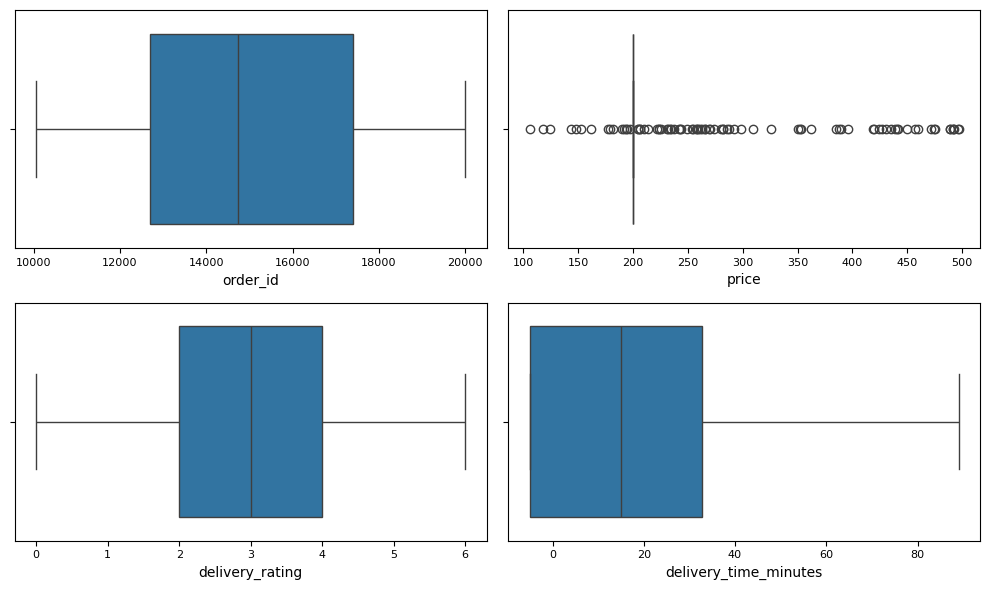

In [33]:
# Visualise outliers using boxplots
plt.figure(figsize = (10, 6))

# Remove outliers using IQR
for k, col in enumerate(num_cols[:4], start = 1):
    plt.subplot(2, 2, k)
    sns.boxplot(x = df[col])
    plt.xticks(fontsize = 8)
    plt.yticks(fontsize = 8)

plt.tight_layout()
plt.show()

Boxplots help us understand the spread, central tendency, and presence of outliers in numerical variables. For instance, the `'price'` column shows many outliers. But before deciding to remove or cap outlier values, we need to make sure that this does not negatively affect the downstream proceses in the pipeline.

In [34]:
# Data that remains if we remove outliers from the price column
df[(df['price'] >= df['price'].quantile(0.25)) & (df['price'] <= df['price'].quantile(0.75))]['price']

0      200.0
1      200.0
2      200.0
3      200.0
5      200.0
       ...  
344    200.0
345    200.0
346    200.0
347    200.0
349    200.0
Name: price, Length: 265, dtype: float64

In [35]:
df[(df['price'] >= df['price'].quantile(0.25)) & (df['price'] <= df['price'].quantile(0.75))]['price'].describe()

count    265.0
mean     200.0
std        0.0
min      200.0
25%      200.0
50%      200.0
75%      200.0
max      200.0
Name: price, dtype: float64

It looks like applying the IQR method to the price column might end up making it redundant. We can choose to retain the column or deal with it differently.

### Filtering Data by Business Objective
The cleaned dataset can then be filtered to focus on recent trends, performance, and operational patterns relevant to the business. Selecting only orders from the last six months for focused analysis in this case makes sense.

In [36]:
df_recent = df[df['order_date'] >= pd.to_datetime('2024-06-01')]  # Filter recent orders

### Exporting the Cleaned Dataset
Save the processed dataset in CSV, Excel, or other formats for downstream use.

In [37]:
df.to_csv('clean_food_delivery_dataset_interim.csv', index = False)  # CSV